# 2. Which product categories are growing, and is the growth real?

The whole marketplace grew fast in 2017, so almost every category's revenue line goes up. The more useful question is **which categories grew faster than the marketplace**, i.e. gained share.

**Setup**
- Revenue = item price (no freight) on orders that were not canceled or unavailable.
- Full months only: January 2017 to August 2018. 2016 has only a few test orders and September 2018 onward is almost empty.
- Top 10 categories by total revenue.

**Tests**, per category:
1. Mann-Kendall trend test on monthly revenue (is there a monotonic trend at all?).
2. Mann-Kendall on the category's **share** of monthly revenue (is it growing faster than everything else?).
3. Average monthly growth from a log-linear fit.

Ten categories means ten tests, so p-values are Holm-adjusted.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root, for `analysis` and `common`

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from analysis.stats import holm, mann_kendall
from common.db import query

START, END = "2017-01-01", "2018-09-01"

In [2]:
monthly = query("""
select
    date_trunc('month', purchase_date)::date as month,
    category,
    sum(price) as revenue
from marts.fct_order_items
where order_status not in ('canceled', 'unavailable')
  and purchase_date >= :start and purchase_date < :end
group by 1, 2
""", start=START, end=END)

wide = monthly.pivot(index="month", columns="category", values="revenue").fillna(0).sort_index()
total = wide.sum(axis=1)
top10 = wide.sum().sort_values(ascending=False).index[:10]
print(f"{len(wide)} months, {wide.shape[1]} categories; top 10 = {wide[top10].sum().sum() / total.sum():.0%} of revenue")

20 months, 74 categories; top 10 = 62% of revenue


In [3]:
rows = []
for cat in top10:
    rev = wide[cat].astype(float)
    share = rev / total
    tau_rev, p_rev = mann_kendall(rev)
    tau_share, p_share = mann_kendall(share)
    # log-linear slope -> average month over month growth
    y = np.log(rev.clip(lower=1))
    slope = np.polyfit(np.arange(len(y)), y, 1)[0]
    rows.append({
        "category": cat,
        "revenue_total": rev.sum(),
        "share_first_6m": rev[:6].sum() / total[:6].sum(),
        "share_last_6m": rev[-6:].sum() / total[-6:].sum(),
        "monthly_growth": np.exp(slope) - 1,
        "tau_revenue": tau_rev, "p_revenue": p_rev,
        "tau_share": tau_share, "p_share": p_share,
    })

res = pd.DataFrame(rows)
res["p_revenue_holm"] = holm(res["p_revenue"])
res["p_share_holm"] = holm(res["p_share"])


def verdict(r):
    if r.p_share_holm < 0.05:
        return "gaining share" if r.tau_share > 0 else "losing share"
    return "moving with the market"


res["verdict"] = res.apply(verdict, axis=1)
res.sort_values("tau_share", ascending=False).style.format({
    "revenue_total": "{:,.0f}", "share_first_6m": "{:.1%}", "share_last_6m": "{:.1%}",
    "monthly_growth": "{:+.1%}", "tau_revenue": "{:.2f}", "p_revenue": "{:.4f}",
    "tau_share": "{:+.2f}", "p_share": "{:.4f}", "p_revenue_holm": "{:.4f}", "p_share_holm": "{:.4f}",
})

,category,revenue_total,share_first_6m,share_last_6m,monthly_growth,tau_revenue,p_revenue,tau_share,p_share,p_revenue_holm,p_share_holm,verdict
1,watches_gifts,"1,194,825",6.7%,10.3%,+11.8%,0.73,0.0000,+0.60,0.0001,0.0000,0.0008,gaining share
6,housewares,"625,539",4.3%,5.8%,+11.7%,0.82,0.0000,+0.39,0.0164,0.0000,0.1148,moving with the market
0,health_beauty,"1,251,146",8.1%,11.0%,+10.7%,0.89,0.0000,+0.37,0.0237,0.0000,0.1424,moving with the market
8,auto,"585,177",4.7%,4.8%,+9.6%,0.80,0.0000,+0.22,0.1859,0.0000,0.7435,moving with the market
2,bed_bath_table,"1,035,485",6.9%,7.2%,+9.3%,0.56,0.0004,+0.13,0.4605,0.0014,0.9567,moving with the market
4,computers_accessories,"902,923",7.2%,5.8%,+8.4%,0.45,0.0047,-0.08,0.6308,0.0142,0.9567,moving with the market
3,sports_leisure,"977,729",7.2%,6.5%,+7.6%,0.60,0.0001,-0.17,0.3189,0.0005,0.9567,moving with the market
5,furniture_decor,"721,584",6.0%,5.3%,+6.3%,0.62,0.0001,-0.29,0.0740,0.0003,0.3701,moving with the market
7,cool_stuff,"619,724",6.7%,2.9%,+1.9%,0.06,0.7246,-0.65,0.0000,0.7246,0.0002,losing share
9,garden_tools,"479,650",4.9%,2.9%,+3.5%,0.41,0.0111,-0.68,0.0000,0.0222,0.0001,losing share


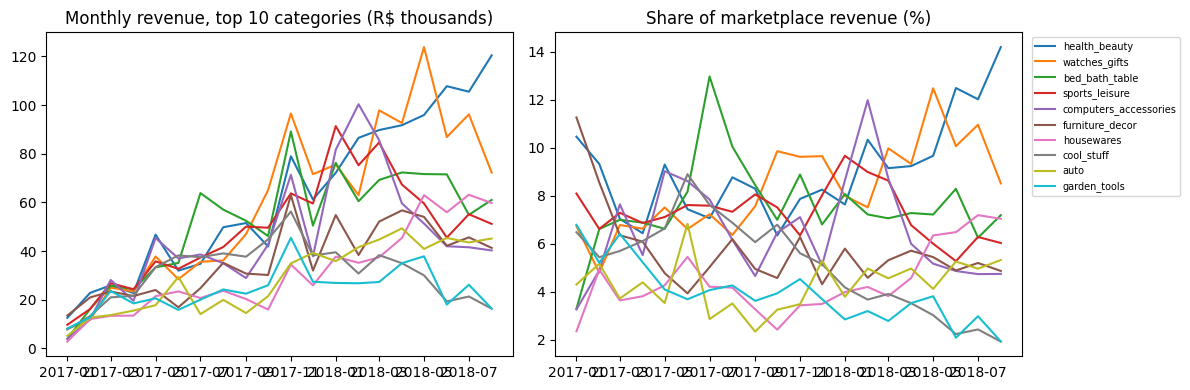

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
wide[top10].div(1000).plot(ax=axes[0], legend=False)
axes[0].set_title("Monthly revenue, top 10 categories (R$ thousands)")
axes[0].set_xlabel("")
wide[top10].div(total, axis=0).mul(100).plot(ax=axes[1])
axes[1].set_title("Share of marketplace revenue (%)")
axes[1].set_xlabel("")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Limitations
- 20 monthly points is a short series. Mann-Kendall doesn't assume a straight line or normal errors, but it does assume the months are independent, and sales months are autocorrelated, so the p-values are somewhat optimistic.
- November 2017 (Black Friday) is a large one-off spike. It sits in the middle of the series, so it affects the log-linear growth figure more than the rank-based test.
- Category labels come from the sellers, so some products are probably in the wrong category.

## What this means for the business

Most of the "growth" in individual categories is just the marketplace growing. Of the top 10 categories, only **watches_gifts** clearly gained share (6.7% → 10.3% of revenue, Holm-adjusted p < 0.001).

**cool_stuff** (6.7% → 2.9%) and **garden_tools** (4.9% → 2.9%) clearly lost share. cool_stuff's revenue didn't grow at all in a market that grew every month. housewares and health_beauty look like they gained share, but the trend doesn't survive the multiple-testing correction, so treat them as "watch" rather than "invest".